# Fig. 3(b) Reproduction With `bloqade-decoders`

This notebook reproduces the Gemini logical simulator workflow for Fig. 3(b) of `arXiv:2412.15165v1`, while using the decoder implementations from the local `bloqade-decoders` checkout instead of notebook-local decoder code.

What is notebook-local vs decoder-local here:
- The Gemini logical hardware kernels, detector mappings, simulator tasks, tomography, and plotting live in this notebook.
- The MLE decoder is `GurobiDecoder` from the local `bloqade-decoders` repo, using its paper-style logical-gap confidence score.
- The MLD decoder is `TableDecoder` from the local `bloqade-decoders` repo, trained from simulator samples. In this notebook its `decode_with_confidence` score is provided by a demo-side wrapper around ancilla-pattern scores learned from simulated output fidelity.

Notes:
- The paper's exact MLD postselection ranks syndrome patterns by the output fidelity they induce. This notebook follows that idea by wrapping `TableDecoder` with a task-specific confidence table, then applying a continuous threshold sweep over that scalar score.
- The notebook prepends the sibling `../bloqade-decoders/src` path so it uses the current working tree, including the new MLE logical-gap support.
- The default configuration is interactive rather than paper-scale.



In [1]:
import itertools
import math
import sys
from collections import Counter
from pathlib import Path

import beliefmatching
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

# import stim

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = candidate.resolve()
    if (candidate / "demo" / "msd_utils").exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate repo root containing demo/msd_utils.")

LOCAL_DECODER_SRC_CANDIDATES = [
    Path.cwd() / ".." / "bloqade-decoders" / "src",
    Path.cwd() / "bloqade-decoders" / "src",
    Path.cwd().parent / "bloqade-decoders" / "src",
    Path.cwd().parent.parent / "bloqade-decoders" / "src",
]
for candidate in LOCAL_DECODER_SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate sibling bloqade-decoders/src checkout.")

import bloqade.decoders as bloqade_decoders  # noqa: E402
from bloqade.decoders import GurobiDecoder, TableDecoder  # noqa: E402
from demo.msd_utils import (  # noqa: E402
    DEFAULT_BASIS_LABELS,
    BasisDataset,
    apply_special_tsim_circuit_strategy,
    build_decoder_kernel_bundle,
    build_injected_kernel_bundle,
    build_measurement_maps,
    build_mld_decoders_from_pair,
    build_mle_decoders,
    build_msd_primitives,
    build_task_map,
    estimate_mld_ancilla_scores,
    evaluate_curve,
    fidelity_from_counts,
    injected_baseline,
    logical_expectation,
    run_task,
    split_factory_bits,
    train_mld_decoder_pair,
)
from demo.msd_utils.domain.kernels import _build_tomography_primitives  # noqa: E402
from demo.msd_utils.domain.layout import _ancilla_matches_valid_targets  # noqa: E402
from demo.msd_utils.domain.special_tasks import _build_task  # noqa: E402
from demo.msd_utils.standard.dem import (  # noqa: E402
    _compute_dem_data,
    _make_layout_only_dem,
)

from bloqade import qubit  # noqa: E402
from bloqade.gemini import logical as gemini_logical  # noqa: E402
from bloqade.gemini.logical.stdlib import default_post_processing  # noqa: E402
from bloqade.lanes import GeminiLogicalSimulator  # noqa: E402

print("Using bloqade.decoders from:", Path(bloqade_decoders.__file__).resolve())

Using bloqade.decoders from: /Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-decoders/src/bloqade/decoders/__init__.py


In [2]:
FAST_CONFIG = {
    "mld_train_shots": 20_000,
    "eval_shots": 4_000,
    "binary_precision": 7,
    "mle_threshold_points": 24,
    "mld_threshold_points": 24,
    "mle_threshold_policy": "quantile",
    "mld_threshold_policy": "linear_range",
    "mld_selection_mode": "threshold",
    "uncertainty_backend": "wilson",
    # 'batch_size': 10_000,
}

PAPER_SCALE_CONFIG = {
    "mld_train_shots": 1_000_000_000,
    "eval_shots": 250_000,
    "binary_precision": 9,
    "mle_threshold_points": 64,
    "mld_threshold_points": 64,
    "mle_threshold_policy": "quantile",
    "mld_threshold_policy": "quantile",
    "mld_selection_mode": "threshold",
    "uncertainty_backend": "wilson",
    # 'batch_size': 50_000,
}

PAPER_SCALE_CONFIG["mld_train_shots"] = 10_000_000
PAPER_SCALE_CONFIG["eval_shots"] = 1_000_000
CONFIG = PAPER_SCALE_CONFIG.copy()
SIM_TYPE = "clifft"
if SIM_TYPE not in {"tsim", "clifft"}:
    raise ValueError(
        f"SIM_TYPE is {SIM_TYPE}; currently, the only supported simulator "
        "backends are 'tsim' and 'clifft'."
    )

_ORIGINAL_RUN_TASK = globals().get("_ORIGINAL_RUN_TASK", run_task)


def run_task(*args, **kwargs):
    kwargs.setdefault("sim_type", SIM_TYPE)
    return _ORIGINAL_RUN_TASK(*args, **kwargs)


PLOT_CONFIG = {
    "min_accepted_fraction": 0.02,
}

PREP_NOISE_CONFIG = {
    "model": "u3_offsets",
    "theta_offset": 0.30,
    "phi_offset": 0.0,
    "lam_offset": 0.0,
}

# Magic-state preparation knobs.
#
# The same U3 preparation is used for the injected reference and for each
# encoded magic state fed into the 5-to-1 distillation circuit. To add a
# simple coherent preparation error, edit the *_OFFSET values below.
IDEAL_THETA = 0.3041 * math.pi
IDEAL_PHI = 0.25 * math.pi
IDEAL_LAM = 0.0

if PREP_NOISE_CONFIG["model"] != "u3_offsets":
    raise ValueError("Only the 'u3_offsets' prep-noise model is currently implemented.")

THETA_OFFSET = PREP_NOISE_CONFIG["theta_offset"]
PHI_OFFSET = PREP_NOISE_CONFIG["phi_offset"]
LAM_OFFSET = PREP_NOISE_CONFIG["lam_offset"]

THETA = IDEAL_THETA + THETA_OFFSET
PHI = IDEAL_PHI + PHI_OFFSET
LAM = IDEAL_LAM + LAM_OFFSET

BASIS_LABELS = DEFAULT_BASIS_LABELS
OUTPUT_QUBIT = 0
ANCILLA_QUBITS = (1, 2, 3, 4)
VALID_FACTORY_TARGETS = np.array([[0, 0, 0, 0]], dtype=np.uint8)
SPECIAL_KERNEL_STRATEGY = "compiled_inverse_prefix"

_MSD_PRIMITIVES = build_msd_primitives(THETA, PHI, LAM)
msd_forward = _MSD_PRIMITIVES["logical_circuit"]

_TOMOGRAPHY_PRIMITIVES = _build_tomography_primitives(output_qubit=OUTPUT_QUBIT)
tomography_x = _TOMOGRAPHY_PRIMITIVES["tomography_x"]
tomography_y = _TOMOGRAPHY_PRIMITIVES["tomography_y"]
tomography_z = _TOMOGRAPHY_PRIMITIVES["tomography_z"]

# This notebook's tomography/sign conventions historically evaluated fidelity
# against the (1, 1, 1) direction after applying notebook-specific sign vectors.
FIDELITY_TARGET_BLOCH = np.ones(3, dtype=np.float64) / np.sqrt(3.0)


def u3_prep_bloch(theta: float, phi: float) -> np.ndarray:
    return np.array(
        [
            math.sin(theta) * math.cos(phi),
            math.sin(theta) * math.sin(phi),
            math.cos(theta),
        ],
        dtype=np.float64,
    )


PREP_BLOCH = u3_prep_bloch(THETA, PHI)
PREP_FIDELITY = 0.5 + float(np.dot(PREP_BLOCH, FIDELITY_TARGET_BLOCH)) / 2.0

MSD_MEASUREMENT_MAPS = build_measurement_maps(5)
INJECTED_MEASUREMENT_MAPS = build_measurement_maps(1)

kernel_bundle = build_decoder_kernel_bundle(
    _MSD_PRIMITIVES,
    output_qubit=OUTPUT_QUBIT,
    special_kernel_strategy=SPECIAL_KERNEL_STRATEGY,
)
injected_kernel_bundle = build_injected_kernel_bundle(
    THETA,
    PHI,
    LAM,
    output_qubit=OUTPUT_QUBIT,
)
ACTUAL_KERNELS = kernel_bundle.actual
SPECIAL_KERNELS = kernel_bundle._special
INJECTED_KERNELS = injected_kernel_bundle.actual
INJECTED_DECODER_KERNELS = injected_kernel_bundle._special

In [3]:
INJECTED_MEASUREMENT_MAPS[0]

[[1, 0, 0], [1, 1, 0], [1, 1, 1], [1, 0, 1], [0, 1, 1], [0, 1, 0], [0, 0, 1]]

In [4]:
INJECTED_MEASUREMENT_MAPS[1]

[[1], [1], [0], [0], [0], [1], [0]]

In [5]:
MSD_MEASUREMENT_MAPS[0]

[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [6]:
MSD_MEASUREMENT_MAPS[1]

[[1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0]]

In [7]:
print("Magic-state prep parameters:")
print("  ideal (theta, phi, lam) =", (IDEAL_THETA, IDEAL_PHI, IDEAL_LAM))
print("  offsets                  =", (THETA_OFFSET, PHI_OFFSET, LAM_OFFSET))
print("  actual (theta, phi, lam) =", (THETA, PHI, LAM))
print("  prep Bloch vector        =", tuple(float(x) for x in PREP_BLOCH))
print("  prep fidelity vs target  =", PREP_FIDELITY)

Magic-state prep parameters:
  ideal (theta, phi, lam) = (0.955358325956656, 0.7853981633974483, 0.0)
  offsets                  = (0.3, 0.0, 0.0)
  actual (theta, phi, lam) = (1.255358325956656, 0.7853981633974483, 0.0)
  prep Bloch vector        = (0.6722185482696245, 0.6722185482696243, 0.3102328911069188)
  prep fidelity vs target  = 0.9776620813937549


In [ ]:
MLD_SIGN_VECTOR = (1.0, -1.0, 1.0)
# The injected corrected baseline now trains its TableDecoder on the
# deterministic surrogate kernels but still evaluates the physical U3
# injected kernels. That means the final injected fidelity estimate must
# keep the raw injected tomography convention, including the Y-sign flip.
INJECTED_RAW_SIGN_VECTOR = (1.0, -1.0, 1.0)
INJECTED_CORRECTED_SIGN_VECTOR = INJECTED_RAW_SIGN_VECTOR
DEFAULT_SIGN_VECTOR = MLD_SIGN_VECTOR

_shared_fidelity_from_counts = fidelity_from_counts


def fidelity_from_counts(
    x_bits, y_bits, z_bits, binary_precision, sign_vector=(1.0, 1.0, 1.0)
):
    return _shared_fidelity_from_counts(
        x_bits,
        y_bits,
        z_bits,
        binary_precision,
        sign_vector=sign_vector,
        target_bloch=FIDELITY_TARGET_BLOCH,
    )

In [9]:
def injected_baseline_raw(task_map, binary_precision: int | None):
    return injected_baseline(
        task_map,
        eval_shots=CONFIG["eval_shots"],
        binary_precision=binary_precision,
        table_decoder_cls=TableDecoder,
        sign_vector=INJECTED_RAW_SIGN_VECTOR,
        target_bloch=FIDELITY_TARGET_BLOCH,
        raw=True,
        basis_labels=BASIS_LABELS,
        sim_type=SIM_TYPE,
    )

In [10]:
sim = GeminiLogicalSimulator()

actual_tasks = build_task_map(
    sim,
    ACTUAL_KERNELS,
    m2dets=MSD_MEASUREMENT_MAPS[0],
    m2obs=MSD_MEASUREMENT_MAPS[1],
    append_measurements=False,
)
special_tasks = build_task_map(
    sim,
    SPECIAL_KERNELS,
    m2dets=MSD_MEASUREMENT_MAPS[0],
    m2obs=MSD_MEASUREMENT_MAPS[1],
    append_measurements=False,
)
special_tasks = apply_special_tsim_circuit_strategy(
    special_tasks,
    SPECIAL_KERNEL_STRATEGY,
)
injected_tasks = build_task_map(
    sim,
    INJECTED_KERNELS,
    m2dets=INJECTED_MEASUREMENT_MAPS[0],
    m2obs=INJECTED_MEASUREMENT_MAPS[1],
    append_measurements=False,
)
injected_decoder_tasks = build_task_map(
    sim,
    INJECTED_DECODER_KERNELS,
    m2dets=INJECTED_MEASUREMENT_MAPS[0],
    m2obs=INJECTED_MEASUREMENT_MAPS[1],
    append_measurements=False,
)

print("Compiled tasks:")
print(" actual:", list(actual_tasks))
print(" special:", list(special_tasks))
print(" injected:", list(injected_tasks))
print(" injected decoder:", list(injected_decoder_tasks))

print("Injected tomography diagnostic (noiseless <labeled basis>):")
for basis, task in injected_tasks.items():
    data = run_task(task, 4000, with_noise=False)
    mean_value = float(
        np.mean(1.0 - 2.0 * np.asarray(data.observables, dtype=np.float64)[:, 0])
    )
    print(f"  {basis}: {mean_value:.6f}")

for basis, task in special_tasks.items():
    data = run_task(task, 64, with_noise=False)
    print(
        basis,
        "special-state noiseless observables:",
        sorted({tuple(row) for row in data.observables}),
    )

Compiled tasks:
 actual: ['X', 'Y', 'Z']
 special: ['X', 'Y', 'Z']
 injected: ['X', 'Y', 'Z']
 injected decoder: ['X', 'Y', 'Z']
Injected tomography diagnostic (noiseless <labeled basis>):
  X: 0.678500
  Y: -0.687000
  Z: 0.287500
X special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Y special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Z special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]


In [11]:
for basis, task in injected_decoder_tasks.items():
    data = run_task(task, 64, with_noise=False)
    print(
        basis,
        "injected-decoder noiseless observables:",
        sorted({tuple(row) for row in data.observables}),
    )

X injected-decoder noiseless observables: [(np.uint8(0),)]
Y injected-decoder noiseless observables: [(np.uint8(0),)]
Z injected-decoder noiseless observables: [(np.uint8(0),)]


In [12]:
injected_decoder_tasks["Z"].tsim_circuit.diagram(height=500)

In [13]:
# NOTE, 4/13, 5:49 PM : reviewed code up to here; looks reasonable

In [14]:
for basis, task in injected_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

X [[0]
 [1]]
Y [[0]
 [1]]
Z [[0]
 [1]]


In [15]:
ACTUAL_KERNELS, SPECIAL_KERNELS, INJECTED_KERNELS

({'X': Method("msd_actual_x"),
  'Y': Method("msd_actual_y"),
  'Z': Method("msd_actual_z")},
 {'X': Method("msd_actual_x"),
  'Y': Method("msd_actual_y"),
  'Z': Method("msd_actual_z")},
 {'X': Method("injected_x"),
  'Y': Method("injected_y"),
  'Z': Method("injected_z")})

In [16]:
injected_tasks["X"].noiseless_tsim_circuit.diagram(height=500)

In [17]:
special_tasks["X"].noiseless_tsim_circuit.diagram(height=500)

In [18]:
type(special_tasks)

dict

In [19]:
special_tasks

{'X': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_actual_x"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise"), logical_initialize_clean=Method("steane7_initialize"), logical_initialize_noisy=Method("noisy_initialize")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x12302c620>), observable_frame=<_ObservableFrame.NOISELESS_REFERENCE_FLIPS: 'noiseless_reference_flips'>, observable_reference=array([0, 0, 0, 0, 0], dtype=uint8), metadata={'logical_kernel': Method("msd_actual_x")}),
 'Y': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_actual_y"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method(

In [20]:
x_task_test = special_tasks["X"]

In [21]:
diagram = x_task_test.tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [22]:
# x_task_test.run(1, with_noise=False, run_detectors=True)

In [23]:
# x_task_test.run(1, with_noise=True, run_detectors=True)

In [24]:
# result = x_task_test.run(20000, with_noise=False, run_detectors=True)

In [25]:
# det = np.asarray(result.detectors, dtype=np.uint8)

In [26]:
# obs = np.asarray(result.observables, dtype=np.uint8)

In [27]:
# result_noisy = x_task_test.run(20000, with_noise=True, run_detectors=True)

In [28]:
# det_noisy = np.asarray(result_noisy.detectors, dtype=np.uint8)

In [29]:
# obs_noisy = np.asarray(result.observables, dtype=np.uint8)

In [30]:
special_tasks

{'X': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_actual_x"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise"), logical_initialize_clean=Method("steane7_initialize"), logical_initialize_noisy=Method("noisy_initialize")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x12302c620>), observable_frame=<_ObservableFrame.NOISELESS_REFERENCE_FLIPS: 'noiseless_reference_flips'>, observable_reference=array([0, 0, 0, 0, 0], dtype=uint8), metadata={'logical_kernel': Method("msd_actual_x")}),
 'Y': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_actual_y"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method(

In [31]:
# Conservative cell
# CONFIG['mld_train_shots'] = 5000

In [32]:
def build_mld_decoders_debug(training_dataset: BasisDataset):
    print(
        "det shape/dtype:",
        training_dataset.detectors.shape,
        training_dataset.detectors.dtype,
    )
    print(
        "obs shape/dtype:",
        training_dataset.observables.shape,
        training_dataset.observables.dtype,
    )

    det = np.ascontiguousarray(training_dataset.detectors, dtype=bool)
    obs = np.ascontiguousarray(training_dataset.observables, dtype=bool)
    print("det contiguous:", det.flags["C_CONTIGUOUS"], det.nbytes)
    print("obs contiguous:", obs.flags["C_CONTIGUOUS"], obs.nbytes)

    anc_det, anc_obs = split_factory_bits(det, obs)
    print("anc det/obs:", anc_det.shape, anc_obs.shape)

    full_dem = _make_layout_only_dem(det.shape[1], obs.shape[1])
    factory_dem = _make_layout_only_dem(anc_det.shape[1], anc_obs.shape[1])
    print(
        "dem sizes:",
        full_dem.num_detectors,
        full_dem.num_observables,
        factory_dem.num_detectors,
        factory_dem.num_observables,
    )

    full_shots = np.ascontiguousarray(np.concatenate([det, obs], axis=1), dtype=bool)
    factory_shots = np.ascontiguousarray(
        np.concatenate([anc_det, anc_obs], axis=1), dtype=bool
    )
    print("full shots:", full_shots.shape, full_shots.dtype, full_shots.nbytes)
    print(
        "factory shots:", factory_shots.shape, factory_shots.dtype, factory_shots.nbytes
    )

    print("building full decoder...")
    full_decoder = TableDecoder.from_det_obs_shots(full_dem, full_shots)
    print(
        "built full decoder:",
        full_decoder.det_obs_counts.shape,
        full_decoder.det_obs_counts.nbytes,
    )

    print("building factory decoder...")
    factory_decoder = TableDecoder.from_det_obs_shots(factory_dem, factory_shots)
    print(
        "built factory decoder:",
        factory_decoder.det_obs_counts.shape,
        factory_decoder.det_obs_counts.nbytes,
    )

    return full_decoder, factory_decoder

In [33]:
# dataset = run_task(special_tasks["X"], 20000, with_noise=True)
# full_decoder, factory_decoder = build_mld_decoders_debug(dataset)

In [34]:
# import time

# task = special_tasks["X"]
# for shots in [100, 1000, 5000, 10000, 100000, 500000, 1000000]:
#     t0 = time.perf_counter()
#     _ = run_task(task, shots, with_noise=True)
#     dt = time.perf_counter() - t0
#     rate = shots / dt
#     print({
#         "shots": shots,
#         "seconds": dt,
#         "shots_per_sec": rate,
#         "hours_for_1b": 1_000_000_000 / rate / 3600,
#     })

In [35]:
injected_tasks["X"].tsim_circuit.diagram(height=500)

In [36]:
injected_summary_raw = injected_baseline_raw(
    injected_tasks, CONFIG["binary_precision"]
)

In [37]:
injected_summary_raw

{'point': 0.9505526030702003,
 'median': 0.9505526030702003,
 'low': 0.949729619307073,
 'high': 0.9513755868333276,
 'error': 0.0008229837631273366,
 'bloch': (0.634422, 0.625476, 0.300862)}

In [38]:
mld_training_data = {}
for basis, task in special_tasks.items():
    print(
        f"Sampling MLD table-training data for {basis} with {CONFIG['mld_train_shots']:,} shots..."
    )
    dataset = run_task(task, CONFIG["mld_train_shots"], with_noise=True)
    mld_training_data[basis] = dataset
    print("cached MLD table-training data")

mld_ranking_train_shots = CONFIG.get("mld_rank_train_shots", CONFIG["mld_train_shots"])
mld_ranking_data = {}
for basis, task in actual_tasks.items():
    print(
        f"Sampling MLD ranking data for {basis} with {mld_ranking_train_shots:,} shots..."
    )
    dataset = run_task(task, mld_ranking_train_shots, with_noise=True)
    mld_ranking_data[basis] = dataset
    print("cached MLD ranking data")

mld_decoder_pairs = {
    basis: train_mld_decoder_pair(dataset, table_decoder_cls=TableDecoder)
    for basis, dataset in mld_training_data.items()
}
mld_ancilla_scores = estimate_mld_ancilla_scores(
    mld_decoder_pairs,
    mld_ranking_data,
    valid_factory_targets=VALID_FACTORY_TARGETS,
    basis_labels=BASIS_LABELS,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
)
mld_training = {
    basis: build_mld_decoders_from_pair(
        full_decoder=mld_decoder_pairs[basis][0],
        factory_decoder=mld_decoder_pairs[basis][1],
        full_syndrome_length=dataset.detectors.shape[1],
        factory_syndrome_length=split_factory_bits(
            dataset.detectors, dataset.observables
        )[0].shape[1],
        ancilla_scores=mld_ancilla_scores,
    )
    for basis, dataset in mld_training_data.items()
}
print("built MLD decoders with shared ancilla-pattern fidelity scores")

Sampling MLD table-training data for X with 10,000,000 shots...
cached MLD table-training data
Sampling MLD table-training data for Y with 10,000,000 shots...
cached MLD table-training data
Sampling MLD table-training data for Z with 10,000,000 shots...
cached MLD table-training data
Sampling MLD ranking data for X with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Y with 10,000,000 shots...
cached MLD ranking data
Sampling MLD ranking data for Z with 10,000,000 shots...
cached MLD ranking data
built MLD decoders with shared ancilla-pattern fidelity scores


In [39]:
mld_training

{'X': DecoderAdapter(full_decoder=<bloqade.decoders._decoders.mld.decoder.TableDecoder object at 0x12617a900>, factory_decoder=TableDecoderWithConfidence(decoder=<bloqade.decoders._decoders.mld.decoder.TableDecoder object at 0x1256bcce0>, syndrome_confidence=array([0.995184  , 0.99641427, 0.98935604, ..., 0.82932293, 0.90113196,
        0.97954592], shape=(4096,)), confidence_score_mode='mld_output_fidelity'), decode_factory=<functools._lru_cache_wrapper object at 0x122af31c0>, decode_full=<functools._lru_cache_wrapper object at 0x122af38a0>, factory_score_mode='mld_output_fidelity'),
 'Y': DecoderAdapter(full_decoder=<bloqade.decoders._decoders.mld.decoder.TableDecoder object at 0x1256bc710>, factory_decoder=TableDecoderWithConfidence(decoder=<bloqade.decoders._decoders.mld.decoder.TableDecoder object at 0x1256bee70>, syndrome_confidence=array([0.995184  , 0.99641427, 0.98935604, ..., 0.82932293, 0.90113196,
        0.97954592], shape=(4096,)), confidence_score_mode='mld_output_fideli

In [40]:
MLD_SIGN_VECTOR

(1.0, -1.0, 1.0)

In [41]:
_compute_dem_data(actual_tasks["X"])

{'H': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 1, 0]], shape=(15, 225)),
 'O': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 1]], shape=(5, 225)),
 'priors': array([0.0113171 , 0.00028568, 0.00202431, 0.0029843 , 0.00121636,
        0.00071681, 0.00161427, 0.00028568, 0.00339222, 0.00214661,
        0.00014286, 0.00014286, 0.00351646, 0.00460779, 0.00625087,
        0.00071681, 0.01240805, 0.00624242, 0.00293184, 0.00111285,
        0.00080665, 0.00028568, 0.00252155, 0.00664766, 0.00028568,
        0.00014286, 0.00014286, 0.00351646, 0.00214661, 0.00948757,
        0.00080665, 0.00551061, 0.01240805, 0.0113171 , 0.0113171 ,
        0.00028568, 0.00488335, 0.00211292, 0.00121636, 0.00211292,
        0.00028568, 0.0

In [42]:
dem_matrix = beliefmatching.detector_error_model_to_check_matrices(
    actual_tasks["X"].detector_error_model,
    allow_undecomposed_hyperedges=True,
)

In [43]:
# dem_matrix.shape

In [ ]:
# NOTE: this cell requires the gurobipy package to be installed

actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}

mle_decoders = {
    basis: build_mle_decoders(
        task,
        gurobi_decoder_cls=GurobiDecoder,
    )
    for basis, task in special_tasks.items()
}

mld_curve = evaluate_curve(
    actual_data,
    mld_training,
    binary_precision=CONFIG["binary_precision"],
    threshold_points=CONFIG["mld_threshold_points"],
    metric="MLD confidence",
    valid_factory_targets=VALID_FACTORY_TARGETS,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    basis_labels=BASIS_LABELS,
    threshold_policy=CONFIG["mld_threshold_policy"],
    selection_mode=CONFIG["mld_selection_mode"],
    uncertainty_backend=CONFIG["uncertainty_backend"],
)
mle_curve = evaluate_curve(
    actual_data,
    mle_decoders,
    binary_precision=CONFIG["binary_precision"],
    threshold_points=CONFIG["mle_threshold_points"],
    metric="MLE logical gap",
    valid_factory_targets=VALID_FACTORY_TARGETS,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    basis_labels=BASIS_LABELS,
    threshold_policy=CONFIG["mle_threshold_policy"],
    uncertainty_backend=CONFIG["uncertainty_backend"],
)
injected_summary_corrected = injected_baseline(
    injected_tasks,
    eval_shots=CONFIG["eval_shots"],
    binary_precision=CONFIG["binary_precision"],
    table_decoder_cls=TableDecoder,
    sign_vector=INJECTED_CORRECTED_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    training_task_map=injected_decoder_tasks,
    basis_labels=BASIS_LABELS,
    uncertainty_backend=CONFIG["uncertainty_backend"],
    sim_type=SIM_TYPE,
)
injected_summary_raw = injected_baseline_raw(
    injected_tasks, CONFIG["binary_precision"]
)

print("Injected raw baseline fidelity:", injected_summary_raw["point"])
print("Injected corrected baseline fidelity:", injected_summary_corrected["point"])
print("MLE score mode:", next(iter(mle_decoders.values())).factory_score_mode)
print("MLE curve points:", len(mle_curve["accepted_fraction"]))
print("MLD curve points:", len(mld_curve["accepted_fraction"]))

Restricted license - for non-production use only - expires 2027-11-29
Injected raw baseline fidelity: 0.9510924255718924
Injected corrected baseline fidelity: 0.9658425702491491
MLE score mode: logical_gap
MLE curve points: 35
MLD curve points: 45


In [45]:
INJECTED_RAW_SIGN_VECTOR, INJECTED_CORRECTED_SIGN_VECTOR

((1.0, -1.0, 1.0), (1.0, -1.0, 1.0))

In [46]:
MLD_SIGN_VECTOR

(1.0, -1.0, 1.0)

In [47]:
FIDELITY_TARGET_BLOCH

array([0.57735027, 0.57735027, 0.57735027])

In [48]:
injected_summary_corrected

{'point': 0.9658425702491491,
 'median': 0.9658425702491491,
 'low': 0.965032235034454,
 'high': 0.9666529054638442,
 'error': 0.0008103352146951117,
 'bloch': (0.655742, 0.652054, 0.30593)}

In [49]:
injected_tasks

{'X': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_x"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise"), logical_initialize_clean=Method("steane7_initialize"), logical_initialize_noisy=Method("noisy_initialize")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x124e30dd0>), observable_frame=<_ObservableFrame.RAW: 'raw'>, observable_reference=None, metadata={'logical_kernel': Method("injected_x")}),
 'Y': DemoTask(task=GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_y"), noise_model=SimpleLogicalNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpa

In [50]:
diagram = injected_tasks["X"].tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [51]:
diagram = actual_tasks["X"].tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [52]:
injected_summary_corrected

{'point': 0.9658425702491491,
 'median': 0.9658425702491491,
 'low': 0.965032235034454,
 'high': 0.9666529054638442,
 'error': 0.0008103352146951117,
 'bloch': (0.655742, 0.652054, 0.30593)}

In [53]:
len(data.observables[:, 0])

256

In [54]:
for basis, task in injected_tasks.items():
    data = run_task(task, 1000, with_noise=False)
    print(basis, logical_expectation(data.observables[:, 0]))

X 0.654
Y -0.696
Z 0.334


In [55]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

X [[0 0 0 0 0]]
Y [[0 0 0 0 0]]
Z [[0 0 0 0 0]]


In [56]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "output unique:", np.unique(data.observables[:, 0]))
    print(basis, "ancilla unique rows:", np.unique(data.observables[:, 1:], axis=0))

X output unique: [0]
X ancilla unique rows: [[0 0 0 0]]
Y output unique: [0]
Y ancilla unique rows: [[0 0 0 0]]
Z output unique: [0]
Z ancilla unique rows: [[0 0 0 0]]


In [57]:
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.plot(mle_curve['accepted_fraction'], mle_curve['fidelity'], color='tab:blue', label='Distilled (MLE)')
# ax.fill_between(
#     mle_curve['accepted_fraction'],
#     mle_curve['credible'][:, 0],
#     mle_curve['credible'][:, 1],
#     color='tab:blue',
#     alpha=0.15,
# )

# ax.plot(mld_curve['accepted_fraction'], mld_curve['fidelity'], color='tab:orange', label='Distilled (MLD)')
# ax.fill_between(
#     mld_curve['accepted_fraction'],
#     mld_curve['credible'][:, 0],
#     mld_curve['credible'][:, 1],
#     color='tab:orange',
#     alpha=0.15,
# )

# # ax.axhline(injected_summary['point'], color='tab:green', linestyle='-', label='Injected')
# plt.axhline(injected_summary['median'], color='green', label='Injected')
# plt.axhspan(
#     injected_summary['low'],
#     injected_summary['high'],
#     color='green',
#     alpha=0.12,
# )

# ax.fill_between(
#     [0.0, 1.0],
#     injected_summary['low'],
#     injected_summary['high'],
#     color='tab:green',
#     alpha=0.1,
# )

# ax.set_xlabel('Total accepted fraction')
# ax.set_ylabel('Magic state fidelity')
# ax.set_title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
# ax.grid(alpha=0.25)
# ax.legend()
# plt.show()

In [58]:
print("Injected summary:", injected_summary_corrected)
print("MLE first few fidelities:", mle_curve["fidelity"][:5])
print("MLD first few fidelities:", mld_curve["fidelity"][:5])

Injected summary: {'point': 0.9658425702491491, 'median': 0.9658425702491491, 'low': 0.965032235034454, 'high': 0.9666529054638442, 'error': 0.0008103352146951117, 'bloch': (0.655742, 0.652054, 0.30593)}
MLE first few fidelities: [0.97882858 0.98660851 0.98588603 0.98628585 0.98651226]
MLD first few fidelities: [0.96916285 0.99462045 0.99457436 0.99447895 0.99446756]


In [59]:
# injected_summary_raw

In [60]:
# injected_summary_corr = injected_baseline(injected_tasks, CONFIG['binary_precision'])

In [61]:
# injected_summary_corr

In [62]:
injected_summary_raw = injected_baseline_raw(
    injected_tasks, CONFIG["binary_precision"]
)

In [63]:
injected_summary_raw

{'point': 0.9498921143622473,
 'median': 0.9498921143622473,
 'low': 0.9490686260527526,
 'high': 0.950715602671742,
 'error': 0.0008234883094947032,
 'bloch': (0.633198, 0.624854, 0.30042)}

In [64]:
mld_curve["accepted_fraction"]

array([0.002195  , 0.038913  , 0.04145333, 0.042646  , 0.04541433,
       0.046889  , 0.04942533, 0.05089333, 0.05253433, 0.05518233,
       0.05646933, 0.058383  , 0.06060033, 0.06245733, 0.06372033,
       0.066952  , 0.06848833, 0.07067733, 0.07166267, 0.07447667,
       0.07594033, 0.07794367, 0.079636  , 0.08176567, 0.083597  ,
       0.08523933, 0.087463  , 0.08944167, 0.09137367, 0.093295  ,
       0.09524233, 0.09720933, 0.09912   , 0.101074  , 0.10300267,
       0.10496333, 0.106886  , 0.108835  , 0.11078567, 0.11271967,
       0.11466333, 0.11660567, 0.118547  , 0.120491  , 0.122433  ])

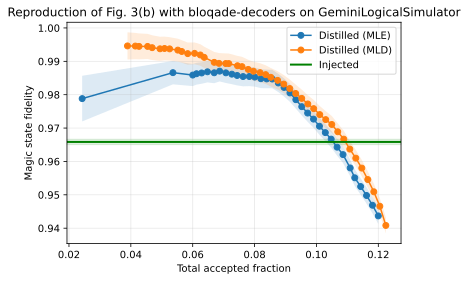

In [65]:
plt.figure(figsize=(6, 4))

PLOT_MIN_ACCEPTED_FRACTION = PLOT_CONFIG["min_accepted_fraction"]
mle_plot_mask = mle_curve["accepted_fraction"] >= PLOT_MIN_ACCEPTED_FRACTION
mld_plot_mask = mld_curve["accepted_fraction"] >= PLOT_MIN_ACCEPTED_FRACTION

plt.plot(
    mle_curve["accepted_fraction"][mle_plot_mask],
    mle_curve["fidelity"][mle_plot_mask],
    marker="o",
    label="Distilled (MLE)",
)
plt.fill_between(
    mle_curve["accepted_fraction"][mle_plot_mask],
    mle_curve["credible"][mle_plot_mask, 0],
    mle_curve["credible"][mle_plot_mask, 1],
    alpha=0.15,
)

plt.plot(
    mld_curve["accepted_fraction"][mld_plot_mask],
    mld_curve["fidelity"][mld_plot_mask],
    marker="o",
    label="Distilled (MLD)",
)
plt.fill_between(
    mld_curve["accepted_fraction"][mld_plot_mask],
    mld_curve["credible"][mld_plot_mask, 0],
    mld_curve["credible"][mld_plot_mask, 1],
    alpha=0.15,
)

plt.axhline(
    injected_summary_corrected["median"],
    color="green",
    linewidth=2,
    label="Injected",
)
plt.axhspan(
    injected_summary_corrected["low"],
    injected_summary_corrected["high"],
    color="green",
    alpha=0.12,
)

plt.xlabel("Total accepted fraction")
plt.ylabel("Magic state fidelity")
plt.title("Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Debugging why the plot is bad

In [ ]:
def summarize_noiseless(task, shots=256, label=""):
    data = run_task(task, shots, with_noise=False)
    obs = data.observables.astype(np.uint8)
    det = data.detectors.astype(np.uint8)
    print(f"{label} detectors shape:", det.shape)
    print(f"{label} observables shape:", obs.shape)
    print(f"{label} unique detector rows:", len(np.unique(det, axis=0)))
    print(f"{label} unique observable rows:", len(np.unique(obs, axis=0)))
    print(f"{label} output unique:", np.unique(obs[:, 0]))
    print(f"{label} ancilla unique rows:", np.unique(obs[:, 1:], axis=0))
    return data

In [69]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_identity_5():
    reg = qubit.qalloc(5)
    return default_post_processing(reg)


dbg_identity_task = _build_task(sim, dbg_identity_5, m2dets=None, m2obs=None)
summarize_noiseless(dbg_identity_task, label="identity_5")

NameError: name 'gemini_logical' is not defined

In [ ]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_x():
    reg = qubit.qalloc(5)
    tomography_x(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_y():
    reg = qubit.qalloc(5)
    tomography_y(reg)
    return default_post_processing(reg)


@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_z():
    reg = qubit.qalloc(5)
    tomography_z(reg)
    return default_post_processing(reg)


for name, kernel in [
    ("tomo_x", dbg_tomo_x),
    ("tomo_y", dbg_tomo_y),
    ("tomo_z", dbg_tomo_z),
]:
    task = _build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)

In [ ]:
for name, kernel in [
    ("tomo_x", dbg_tomo_x),
    ("tomo_y", dbg_tomo_y),
    ("tomo_z", dbg_tomo_z),
]:
    task = _build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)

# Additional debug on why plot is bad

In [ ]:
for basis, task in actual_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "unique full obs:", np.unique(data.observables, axis=0))
    print(basis, "unique ancilla obs:", np.unique(data.observables[:, 1:], axis=0))

In [ ]:
for basis, task in actual_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    anc = data.observables[:, 1:]
    counts = Counter(tuple(map(int, row)) for row in anc)
    print("\n", basis)
    for bitstring, count in counts.most_common(10):
        print(bitstring, count, count / len(anc))

In [ ]:
def injected_baseline_debug(task_map, binary_precision: int | None, shots: int = 4000):
    print("Evaluating injected baseline with SAME data for train and test")
    corrected = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        print(f"\nBasis {basis}")
        print(
            "det shape:",
            dataset.detectors.shape,
            "obs shape:",
            dataset.observables.shape,
        )

        train_det_obs = np.concatenate(
            [dataset.detectors, dataset.observables], axis=1
        ).astype(bool)

        decoder = TableDecoder.from_det_obs_shots(
            _make_layout_only_dem(
                dataset.detectors.shape[1], dataset.observables.shape[1]
            ),
            train_det_obs,
        )

        bits = []
        for det, obs in zip(dataset.detectors, dataset.observables, strict=True):
            flip = np.asarray(decoder.decode(det.astype(bool)), dtype=np.uint8)
            bits.append(int(obs[0] ^ flip[0]))

        bits = np.asarray(bits, dtype=np.uint8)
        corrected[basis] = bits

        print("post-decoding logical mean:", logical_expectation(bits))
        print("logical ones fraction:", float(np.mean(bits)))

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        binary_precision,
        sign_vector=INJECTED_CORRECTED_SIGN_VECTOR,
    )
    print("\nLeaky injected summary:", summary)
    return summary

In [ ]:
_ = injected_baseline_debug(injected_tasks, binary_precision=CONFIG["binary_precision"], shots=4000)

# Check naive postselection

In [ ]:
def naive_injected_baseline(
    task_map,
    binary_precision: int | None,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fractions = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        mask = np.ones(len(dataset.observables), dtype=bool)
        if require_zero_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        binary_precision,
        sign_vector=INJECTED_RAW_SIGN_VECTOR,
    )
    summary["accepted_fraction"] = float(np.mean(list(accepted_fractions.values())))
    summary["accepted_fraction_by_basis"] = accepted_fractions
    return summary


def naive_distilled_summary(
    actual_data,
    valid_factory_targets,
    binary_precision: int | None,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    valid_factory_targets = np.asarray(valid_factory_targets, dtype=np.uint8)

    corrected = {}
    accepted_fractions = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        dataset = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)

        mask = _ancilla_matches_valid_targets(anc_obs, valid_factory_targets)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        binary_precision,
        sign_vector=(1.0, -1.0, 1.0),
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fractions
    summary["valid_factory_targets"] = tuple(
        tuple(int(x) for x in row.tolist())
        for row in np.atleast_2d(valid_factory_targets)
    )
    if np.atleast_2d(valid_factory_targets).shape[0] == 1:
        summary["factory_target"] = tuple(
            int(x) for x in np.atleast_2d(valid_factory_targets)[0].tolist()
        )
    return summary


def scan_naive_factory_targets(
    actual_data,
    binary_precision: int | None,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted(
        {
            tuple(map(int, row))
            for basis in BASIS_LABELS
            for row in actual_data[basis].observables[:, 1:]
        }
    )

    rows = []
    for pattern in patterns:
        try:
            summary = naive_distilled_summary(
                actual_data,
                pattern,
                binary_precision=binary_precision,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append(
            {
                "pattern": pattern,
                "accepted_fraction": summary["accepted_fraction"],
                "median": summary["median"],
                "low": summary["low"],
                "high": summary["high"],
                "bloch": summary["bloch"],
            }
        )

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows

In [ ]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}

In [ ]:
inj_raw = naive_injected_baseline(
    injected_tasks,
    binary_precision=CONFIG["binary_precision"],
    require_zero_detectors=False,
)
inj_ps = naive_injected_baseline(
    injected_tasks,
    binary_precision=CONFIG["binary_precision"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)

In [ ]:
naive_rows = scan_naive_factory_targets(
    actual_data,
    binary_precision=CONFIG["binary_precision"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows[:10]:
    print(row)

In [ ]:
best_pattern = naive_rows[0]["pattern"]
naive_best = naive_distilled_summary(
    actual_data,
    best_pattern,
    binary_precision=CONFIG["binary_precision"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

print("Best naive distilled summary:", naive_best)

In [ ]:
naive_rows_no_flags = scan_naive_factory_targets(
    actual_data,
    binary_precision=CONFIG["binary_precision"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows_no_flags[:10]:
    print(row)

In [ ]:
def scan_noiseless_actual_patterns(task_map, shots: int = 10000):
    from collections import Counter, defaultdict

    rows = []
    pattern_output = defaultdict(lambda: {"X": [], "Y": [], "Z": []})
    pattern_counts = Counter()

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=False)
        anc = data.observables[:, 1:]
        out = data.observables[:, 0]
        for a, o in zip(anc, out, strict=True):
            key = tuple(int(x) for x in a)
            pattern_counts[key] += 1
            pattern_output[key][basis].append(int(o))

    total = sum(pattern_counts.values())

    for key, count in pattern_counts.items():
        if min(len(pattern_output[key][b]) for b in BASIS_LABELS) == 0:
            continue
        x_bits = np.asarray(pattern_output[key]["X"], dtype=np.uint8)
        y_bits = np.asarray(pattern_output[key]["Y"], dtype=np.uint8)
        z_bits = np.asarray(pattern_output[key]["Z"], dtype=np.uint8)
        summary = fidelity_from_counts(
            x_bits, y_bits, z_bits, binary_precision=CONFIG["binary_precision"], sign_vector=(1.0, -1.0, 1.0)
        )
        rows.append(
            {
                "pattern": key,
                "fraction": count / total,
                "median": summary["median"],
                "bloch": summary["bloch"],
            }
        )

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows


rows_noiseless = scan_noiseless_actual_patterns(actual_tasks, shots=10000)
for row in rows_noiseless[:10]:
    print(row)

In [ ]:
def clifford_images_of_magic():
    base = np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)
    images = []
    for perm in itertools.permutations(range(3)):
        for signs in itertools.product([-1, 1], repeat=3):
            vec = np.array([signs[i] * base[perm[i]] for i in range(3)])
            # Keep proper signed permutations from the single-qubit Clifford group
            mat = np.zeros((3, 3), dtype=int)
            for i in range(3):
                mat[i, perm[i]] = signs[i]
            if round(np.linalg.det(mat)) == 1:
                images.append(tuple(np.round(vec, 8)))
    images = sorted(set(images))
    return [np.array(v) for v in images]


def nearest_magic_image(bloch):
    bloch = np.array(bloch, dtype=float)
    candidates = clifford_images_of_magic()
    scored = []
    for cand in candidates:
        scored.append((float(np.dot(bloch, cand)), cand))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:5]


# Example: inspect the suspected accepted branch
bloch = np.array([0.5919335705812574, -0.8640429338103757, 0.5940298507462687])
for score, cand in nearest_magic_image(bloch):
    print("score:", score, "candidate:", cand)

In [ ]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))

In [ ]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))

# Test naive postselection

In [ ]:
def naive_injected_summary(
    task_map,
    binary_precision: int | None,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fraction_by_basis = {}

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=True)
        mask = np.ones(len(data.observables), dtype=bool)

        if require_zero_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        binary_precision,
        sign_vector=INJECTED_RAW_SIGN_VECTOR,
    )
    summary["accepted_fraction"] = float(
        np.mean(list(accepted_fraction_by_basis.values()))
    )
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    return summary

In [ ]:
def naive_distilled_summary(
    actual_data,
    valid_factory_targets,
    binary_precision: int | None,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    valid_factory_targets = np.asarray(valid_factory_targets, dtype=np.uint8)

    corrected = {}
    accepted_fraction_by_basis = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        data = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(data.detectors, data.observables)

        mask = _ancilla_matches_valid_targets(anc_obs, valid_factory_targets)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))
        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        binary_precision,
        sign_vector=(1.0, -1.0, 1.0),
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    summary["valid_factory_targets"] = tuple(
        tuple(int(x) for x in row.tolist())
        for row in np.atleast_2d(valid_factory_targets)
    )
    if np.atleast_2d(valid_factory_targets).shape[0] == 1:
        summary["factory_target"] = tuple(
            int(x) for x in np.atleast_2d(valid_factory_targets)[0].tolist()
        )
    return summary

In [ ]:
def scan_naive_patterns(
    actual_data,
    binary_precision: int | None,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted(
        {
            tuple(map(int, row))
            for basis in BASIS_LABELS
            for row in actual_data[basis].observables[:, 1:]
        }
    )

    rows = []
    for pattern in patterns:
        try:
            s = naive_distilled_summary(
                actual_data,
                pattern,
                binary_precision=binary_precision,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append(
            {
                "pattern": pattern,
                "accepted_fraction": s["accepted_fraction"],
                "median": s["median"],
                "low": s["low"],
                "high": s["high"],
                "bloch": s["bloch"],
            }
        )

    rows.sort(key=lambda r: r["median"], reverse=True)
    return rows

In [ ]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}

inj_raw = naive_injected_summary(
    injected_tasks,
    binary_precision=CONFIG["binary_precision"],
    require_zero_detectors=False,
)

inj_ps = naive_injected_summary(
    injected_tasks,
    binary_precision=CONFIG["binary_precision"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)

In [ ]:
rows_no_decoder = scan_naive_patterns(
    actual_data,
    binary_precision=CONFIG["binary_precision"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder[:10]:
    print(row)

In [ ]:
rows_no_decoder_flagged = scan_naive_patterns(
    actual_data,
    binary_precision=CONFIG["binary_precision"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder_flagged[:10]:
    print(row)

In [ ]:
best_raw = rows_no_decoder[0]
best_flagged = rows_no_decoder_flagged[0]

print("Best naive raw branch:", best_raw)
print("Best naive flagged branch:", best_flagged)
print("Injected raw median:", inj_raw["median"])
print("Injected perfect-stabilizer median:", inj_ps["median"])